#  넷플릭스 데이터 분석 

## 학습 목표
0. 관련 파이썬 문법 복습하기
1. 넷플릭스 데이터를 불러와서 구조를 파악
2. 날짜·문자열 데이터를 분석에 맞게 가공
3. 필터링·집계로 원하는 정보를 뽑아낸다
4. 그래프로 인사이트를 시각화

### 사용 데이터
- `netflix_titles.csv`
- 출처: Kaggle - Netflix Movies and TV Shows


---

## PART 0. 파이썬 핵심 개념 미리 보기

> 데이터 분석에 꼭 필요한 파이썬 기본 문법을 먼저 익혀봅시다.  

### 리스트 (List)

> 여러 값을 **순서대로** 담는 목록입니다. 대괄호 `[]` 로 만듭니다.

```
genres = ['Dramas', 'Comedies', 'Action']
           0번       1번         2번      ← 인덱스(순서번호)는 0부터 시작!
```

> **슬라이싱**: `리스트[시작:끝]` 으로 일부를 잘라낼 수 있습니다.  
> 끝 인덱스는 **포함되지 않습니다**.

In [121]:
genres = ['Dramas', 'Comedies', 'Action', 'Horror', 'Documentary']

In [122]:
genres = ['Dramas', 'Comedies', 'Action', 'Horror', 'Documentary']

#### 인덱싱: 특정 위치의 값 꺼내기

In [123]:
genres[0]

'Dramas'

In [124]:
genres[-1]

'Documentary'

#### 슬라이싱: 일부 잘라내기

In [125]:
print(genres[0:2])

['Dramas', 'Comedies']


#### in: 포함 여부 확인

In [126]:
'Dramas' in  genres

True

In [128]:
'Dramas' in genres

True

In [75]:
print('Action 포함 여부:', 'Action' in genres)  # in: 포함 여부 확인

Action 포함 여부: True


In [129]:
print('Action 포함 여부:', 'Action' in genres)

Action 포함 여부: True


### 반복문 `for` 와 조건문 `if`

> **for 반복문**: 리스트의 값을 하나씩 꺼내 반복 처리합니다.  
> **if 조건문**: 조건이 참일 때만 코드 블록을 실행합니다.

> **중요 규칙**: `for`, `if` 다음 줄은 반드시 **들여쓰기(스페이스 4칸)** 를 해야 합니다!  
> 들여쓰기가 없으면 오류가 납니다.

#### for 반복문 기본

In [77]:
for genre in genres :
    print(genre)    

Dramas
Comedies
Action
Horror
Documentary


In [130]:
for genre in genres :
    print(genre)   

Dramas
Comedies
Action
Horror
Documentary


#### if 조건문과 함께 사용    

In [79]:
tv_genres = ['TV Dramas', 'Comedies', 'TV Action', 'Horror', 'TV Shows']
for genre in tv_genres :
    if 'TV' in genre :
        print('TV 장르')
    else :
        print('Movie 장르')

TV 장르
Movie 장르
TV 장르
Movie 장르
TV 장르


In [131]:
tv_genres = ['TV Dramas', 'Comedies', 'TV Action', 'Horror', 'TV Shows']
for genre in tv_genres :
    if 'TV' in genre :
        print('TV 장르')
    else :
        print('Movie 장르')

TV 장르
Movie 장르
TV 장르
Movie 장르
TV 장르


### 문자열 주요 메서드

> 넷플릭스 데이터에는 문자열 컬럼이 많으니 문자열을 다루는 주요 메서드 사용해보세요 

| 메서드 | 설명 | 예시 |
|--------|------|------|
| `.upper()` | 대문자로 | `'hello'.upper()` → `'HELLO'` |
| `.lower()` | 소문자로 | `'HELLO'.lower()` → `'hello'` |
| `.strip()` | 앞뒤 공백 제거 | `'  hi  '.strip()` → `'hi'` |
| `.split(구분자)` | 구분자로 나누기 | `'a,b,c'.split(',')` → `['a','b','c']` |
| `.replace(a, b)` | a를 b로 교체 | `'90 min'.replace(' min','')` → `'90'` |
| `.contains(검색어)` | 포함 여부 | 문자열 일부 포함 |

#### 문자열 함수 replace(): 특정 문자열을 다른 것으로 교체 

In [132]:
duration_str = '90 min'           # 넷플릭스 영화 상영시간 형식
duration_str.replace(' min','')  # ' min' 을 빈 문자열로 교체                                  

'90'

In [133]:
int(duration_str.replace(' min',''))

90

In [134]:
date_str = ' January 15, 2020 '

In [135]:
date_str.strip()

'January 15, 2020'

In [136]:
genres_str = 'Dramas, International Movies, Comedies'

In [137]:
genres_str = 'Dramas, International Movies, Comedies'
genres_str.split(', ')

['Dramas', 'International Movies', 'Comedies']

---

## PART 1. 라이브러리 불러오기

> **라이브러리**란 다른 사람이 미리 만들어 놓은 코드 묶음입니다.  
> `import 라이브러리이름 as 별명` 으로 가져다 씁니다.

### 우리가 사용할 라이브러리

```
  pandas    → 표(DataFrame) 형태의 데이터 다루기 
  matplotlib → 그래프 그리기 기본 도구
  seaborn   → 더 예쁜 통계 그래프
```

In [138]:
import pandas as pd          
import matplotlib.pyplot as plt   
import seaborn as sns       

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

sns.set_palette('Set2')              # seaborn 색상 팔레트, 부드러운 파스텔톤 색상

---

## PART 2. 넷플릭스 데이터 불러오기

In [88]:
df1 = pd.read_csv('netflix_titles.csv')  # 파일 경로, 같은 폴더에 있으면 파일명만

In [139]:
df1 = pd.read_csv('netflix_titles.csv')

#### 분석용 DataFrame 복사본 만들기 : 원본을 보존하는 것이 좋은 습관

In [90]:
df = df1.copy()

In [140]:
df = df1.copy()

---

## PART 3. 데이터 살펴보기

> 데이터를 불러오면 **제일 먼저** 구조를 파악해야 합니다.  
> 아래 명령어들로 데이터를 다양한 각도로 들여다봅시다.

| 명령어 | 설명 |
|--------|------|
| `df.head(n)` | 앞 n행 출력 (기본 5) |
| `df.tail(n)` | 뒤 n행 출력 |
| `df.info()` | 타입·결측치 요약 |
| `df.shape` | (행 수, 열 수) |
| `df.columns` | 컬럼 이름 목록 |
| `df.describe()` | 수치형 통계 요약 |

In [141]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [142]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [144]:
df.shape

(8807, 12)

In [145]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [146]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


---

## PART 4. 데이터 정제 (결측치 처리)

### 결측치란?

> 데이터가 **비어있음**
> `NaN` (Not a Number) 으로 표시


### 처리 방법

| 방법 | 코드 | 적용 상황 |
|------|------|----------|
| 확인 | `df.isnull().sum()` | 결측치 현황 파악 |
| 채우기 | `df.fillna('Unknown')` | 없어도 분석 가능한 경우 |
| 제거 | `df.dropna(subset=['컬럼'])` | 반드시 값이 있어야 하는 경우 |

In [147]:
df.isnull().sum()         # isnull(): 빈 값이면 True, 값이 있으면 False,  .sum(): True를 1로 세어 합산

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [35]:
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')

In [148]:
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')

In [37]:
df = df.dropna(subset=['date_added', 'duration']) # 해당 열에 빈 값이 있는 행 제거

In [149]:
df = df.dropna(subset=['date_added', 'duration'])

---

## PART 5. 데이터 가공 (타입 변환 & 새 컬럼 만들기)

> 원본 데이터가 분석하기 불편한 형태일 때 **가공**이 필요 
> 예를 들어 날짜가 문자열로 되어 있으면 '몇 월인지' 등의 계산을 못합니다
### 이번 파트에서 할 작업

```
1. date_added: 문자열 → 날짜 타입으로 변환 → 연도/월/일/ (요일) 추출
   'September 25, 2021'  →  2021년 9월 25일

2. duration: 문자열 → 숫자 추출
   '90 min'   →  90 (영화 상영시간)
   '2 Seasons' →  2 (TV쇼 시즌 수)
```

In [150]:
df['date_added'].dtype

dtype('O')

In [41]:
print('변환 전 date_added 타입:', df['date_added'].dtype)

변환 전 date_added 타입: object


In [151]:
print('변환 전 date_added 타입:', df['date_added'].dtype)

변환 전 date_added 타입: object


### 날짜 컬럼 가공 
> pd.to_datetime(): 문자열을 날짜(datetime) 타입으로 변환      
    
> 변환 후에는 .dt.year, .dt.month, .dt.day 등으로 연도,월, 일 등을 꺼낼 수 있음

In [152]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [153]:
df['date_added'].dt.year

0       2021
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2019
8803    2019
8804    2019
8805    2020
8806    2019
Name: date_added, Length: 8794, dtype: int32

In [154]:
df['year_added'] = df['date_added'].dt.year

In [155]:
df['month_added'] = df['date_added'].dt.month

In [156]:
df['day_added'] = df['date_added'].dt.day

---

#### 요일(weekday) 정보도 추출해 봅시다

> `dt.weekday` 는 요일을 **숫자**로 반환합니다.

```
  0 = Monday(월)  1 = Tuesday(화)  2 = Wednesday(수)
  3 = Thursday(목) 4 = Friday(금)   5 = Saturday(토)  6 = Sunday(일)
```

> `dt.day_name()` 은 요일을 **영어 이름**으로 반환합니다.  
> `()` 괄호가 있는 것에 주의! dt.year, dt.month, dt.day 는 속성이라 괄호 없었지만 day_name()은 함수입니다.

In [108]:
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8794, dtype: datetime64[ns]

In [157]:
df['date_added'].dt.weekday

0       5
1       4
2       4
3       4
4       4
       ..
8802    2
8803    0
8804    4
8805    5
8806    5
Name: date_added, Length: 8794, dtype: int32

In [158]:
df['date_added'].dt.day_name()

0        Saturday
1          Friday
2          Friday
3          Friday
4          Friday
          ...    
8802    Wednesday
8803       Monday
8804       Friday
8805     Saturday
8806     Saturday
Name: date_added, Length: 8794, dtype: object

In [53]:
df['date_added'].dt.day_name()

0        Saturday
1          Friday
2          Friday
3          Friday
4          Friday
          ...    
8802    Wednesday
8803       Monday
8804       Friday
8805     Saturday
8806     Saturday
Name: date_added, Length: 8794, dtype: object

---

### duration(영화 상영시간, TV 쇼 시즌) 컬럼 가공 
> 영화: '90 min'  → 숫자 90 추출       
> TV쇼: '2 Seasons' → 숫자 2 추출

#### df 에서 Movie 에 대한 데이터만 선택하여 df_movie 만들기

In [159]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25


In [168]:
df['type'] 

0         Movie
1       TV Show
2       TV Show
3       TV Show
4       TV Show
         ...   
8802      Movie
8803    TV Show
8804      Movie
8805      Movie
8806      Movie
Name: type, Length: 8794, dtype: object

In [169]:
df['type'] == 'Movie'

0        True
1       False
2       False
3       False
4       False
        ...  
8802     True
8803    False
8804     True
8805     True
8806     True
Name: type, Length: 8794, dtype: bool

In [175]:
df_movie = df[df['type'] == 'Movie']

In [176]:
df_movie['duration']

0        90 min
6        91 min
7       125 min
9       104 min
12      127 min
         ...   
8801     96 min
8802    158 min
8804     88 min
8805     88 min
8806    111 min
Name: duration, Length: 6128, dtype: object

In [177]:
df_movie['duration'].str.replace(' min', '').astype(int)

0        90
6        91
7       125
9       104
12      127
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: duration, Length: 6128, dtype: int64

In [178]:
df_movie['duration'] = df_movie['duration'].str.replace(' min', '').astype(int)

In [180]:
df_movie['duration'].mean().round(1)

np.float64(99.6)

In [181]:
df_movie['duration'].max()

312

In [182]:
print(df_movie['duration'].min())

3


#### df 에서 TV Show 에 대한 데이터만 선택하여 df_tv 만들기

In [189]:
df_tv = df[  df['type'] == 'TV Show'    ]

In [190]:
df_tv['duration'].str.replace(' Seasons', '').str.replace(' Season','').astype(int)

1       2
2       1
3       1
4       2
5       1
       ..
8795    2
8796    2
8797    3
8800    1
8803    2
Name: duration, Length: 2666, dtype: int64

In [191]:
df_tv['duration'] = df_tv['duration'].str.replace(' Seasons', '').str.replace(' Season','').astype(int)

In [192]:
df_tv['duration'].min()

1

In [193]:
df_tv['duration'].max()

17

In [194]:
print(f'평균: {df_tv['duration'].mean():.1f}시즌')

평균: 1.8시즌


In [195]:
int('90')

90

- astype(int) → 전체 컬럼(Series) 변환
- int() → 하나의 값만 변환

---

## PART 6. 조건에 맞는 데이터 골라내기 (필터링)

> 전체 8,000여 개 데이터 중 원하는 것만 골라내는 것을 **필터링**이라 합니다.

### 기본 문법

```python
df[조건식]           # 조건이 True인 행(데이터)만 남김
```

### 자주 쓰는 조건 패턴

| 패턴 | 코드 예시 |
|------|----------|
| 같다 | `df['type'] == 'Movie'` |
| 포함 | `df['title'].str.contains('Love')` |
| 여러 값 중 하나 | `df['country'].isin(['South Korea', 'Japan'])` |
| AND 조건 | `(조건1) & (조건2)` |
| OR 조건 | `(조건1) \| (조건2)` |

In [196]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'day_added'],
      dtype='object')

문제 1: 영화(Movie)만 선택

In [197]:
df[ df['type'] == 'Movie'    ]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9,24
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,24
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9,24
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,9,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016,3,9
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11,20
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11,1
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,11


문제 2: 제목에 'Love'가 들어가는 컨텐츠 ?

In [198]:
df[ df['title'].str.contains('Love') ]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
25,s26,TV Show,Love on the Spectrum,Unknown,Brooke Satchwell,Australia,2021-09-21,2021,TV-14,2 Seasons,"Docuseries, International TV Shows, Reality TV",Finding love can be hard for anyone. For young...,2021,9,21
158,s159,Movie,Love Don't Cost a Thing,Troy Byer,"Nick Cannon, Christina Milian, Kenan Thompson,...",United States,2021-09-01,2003,PG-13,101 min,"Comedies, Romantic Movies",A nerdy teen tries to make himself cool by ass...,2021,9,1
159,s160,Movie,Love in a Puff,Pang Ho-cheung,"Miriam Chin Wah Yeung, Shawn Yue, Singh Hartih...",Hong Kong,2021-09-01,2010,TV-MA,103 min,"Comedies, Dramas, International Movies",When the Hong Kong government enacts a ban on ...,2021,9,1
206,s207,Movie,"LSD: Love, Sex Aur Dhokha",Dibakar Banerjee,"Nushrat Bharucha, Anshuman Jha, Neha Chauhan, ...",India,2021-08-27,2010,TV-MA,112 min,"Dramas, Independent Movies, International Movies",This provocative drama examines how the voyeur...,2021,8,27
227,s228,Movie,Really Love,Angel Kristi Williams,"Kofi Siriboe, Yootha Wong-Loi-Sing, Michael Ea...",United States,2021-08-25,2020,TV-MA,95 min,"Dramas, Independent Movies, Romantic Movies",A rising Black painter tries to break into a c...,2021,8,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8567,s8568,TV Show,The Year of Happiness and Love,Unknown,"Amber Kuo, James Wen, Weber Yang, Sonia Sui, N...",Taiwan,2016-09-01,2009,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",Jiang Chen-bo is a loser without prospects for...,2016,9,1
8575,s8576,TV Show,This Is My Love,Unknown,"Jin-mo Joo, Sa-rang Kim, Junior, Ja-in Lee, Su...",South Korea,2017-05-22,2015,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",A renowned actor who is still pining over the ...,2017,5,22
8649,s8650,Movie,Two Lovers and a Bear,Kim Nguyen,"Dane DeHaan, Tatiana Maslany, Gordon Pinsent, ...",Canada,2017-05-02,2016,R,95 min,"Dramas, Independent Movies, Romantic Movies",A troubled couple living near the North Pole b...,2017,5,2
8721,s8722,TV Show,What Is Love?,Unknown,"Chris Wu, Jade Chou, Duncan Lai, King Chin, Ki...",Taiwan,2017-01-01,2012,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",A 32-year-old romantic looking for a long-term...,2017,1,1


In [202]:
len( df[ df['title'].str.contains('Love') ])

188

문제 3: 인도 제작 컨텐츠 ?

In [203]:
df[  df['country'] =='India'   ]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,2021,9,21
39,s40,TV Show,Chhota Bheem,Unknown,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-09-16,2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ...",2021,9,16
50,s51,TV Show,Dharmakshetra,Unknown,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,2021-09-15,2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup...",2021,9,15
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,Unknown,Unknown,India,2021-09-15,2014,TV-G,1 Season,"Docuseries, International TV Shows",Explore the history and flavors of regional In...,2021,9,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,2018-01-01,2006,TV-PG,151 min,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...,2018,1,1
8775,s8776,TV Show,Yeh Meri Family,Unknown,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,2018-08-31,2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal...",2018,8,31
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,2019-12-31,2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...,2019,12,31
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,2018-02-15,2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...,2018,2,15


문제 4: 한국, 일본 제작 컨텐츠 ?

In [204]:
df['country'].value_counts().head(20) 

country
United States                    2809
India                             972
Unknown                           830
United Kingdom                    418
Japan                             244
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          86
Taiwan                             81
Indonesia                          79
Brazil                             77
Philippines                        75
United Kingdom, United States      75
United States, Canada              73
Name: count, dtype: int64

In [205]:
df[  df['country'].isin( ['South Korea' ,'Japan'   ]   )    ]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
51,s52,Movie,InuYasha the Movie 2: The Castle Beyond the Lo...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Mieko Harada...",Japan,2021-09-15,2002,TV-14,99 min,"Action & Adventure, Anime Features, Internatio...","With their biggest foe seemingly defeated, Inu...",2021,9,15
52,s53,Movie,InuYasha the Movie 3: Swords of an Honorable R...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan,2021-09-15,2003,TV-14,99 min,"Action & Adventure, Anime Features, Internatio...",The Great Dog Demon beaqueathed one of the Thr...,2021,9,15
53,s54,Movie,InuYasha the Movie 4: Fire on the Mystic Island,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan,2021-09-15,2004,TV-PG,88 min,"Action & Adventure, Anime Features, Internatio...","Ai, a young half-demon who has escaped from Ho...",2021,9,15
54,s55,Movie,InuYasha the Movie: Affections Touching Across...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan,2021-09-15,2001,TV-PG,100 min,"Action & Adventure, Anime Features, Internatio...",A powerful demon has been sealed away for 200 ...,2021,9,15
56,s57,Movie,Naruto Shippuden the Movie: Blood Prison,Masahiko Murata,"Junko Takeuchi, Chie Nakamura, Rikiya Koyama, ...",Japan,2021-09-15,2011,TV-14,102 min,"Action & Adventure, Anime Features, Internatio...",Mistakenly accused of an attack on the Fourth ...,2021,9,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8463,s8464,Movie,The President's Barber,Chan-sang Lim,"Kang-ho Song, So-ri Moon, Jae-eung Lee, Yeong-...",South Korea,2017-10-01,2004,TV-MA,116 min,"Comedies, Dramas, International Movies","The personal barber to the president, as well ...",2017,10,1
8467,s8468,Movie,The Prison,Na Hyeon,"Suk-kyu Han, Rae-won Kim, Kyeong-yeong Lee, Wo...",South Korea,2017-11-18,2017,TV-MA,125 min,"Action & Adventure, Dramas, International Movies",A cop-turned-convict discovers a crime syndica...,2017,11,18
8575,s8576,TV Show,This Is My Love,Unknown,"Jin-mo Joo, Sa-rang Kim, Junior, Ja-in Lee, Su...",South Korea,2017-05-22,2015,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",A renowned actor who is still pining over the ...,2017,5,22
8613,s8614,Movie,Train to Busan,Sang-ho Yeon,"Gong Yoo, Yu-mi Jung, Dong-seok Ma, Soo-an Kim...",South Korea,2017-03-18,2016,TV-MA,118 min,"Action & Adventure, Horror Movies, Internation...","As a zombie outbreak sweeps the country, a dad...",2017,3,18


문제 5: 한국의 영화만 검색

In [206]:
df[ (df['country'] =='South Korea')  & ( df['type'] =='Movie' ) ]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
556,s557,Movie,The 8th Night,Kim Tae-hyung,"Lee Sung-min, Park Hae-joon, Kim You-jung, Nam...",South Korea,2021-07-02,2021,TV-14,116 min,"Horror Movies, International Movies, Thrillers",With prayer beads in one hand and an ax in the...,2021,7,2
762,s763,Movie,Sweet & Sour,Lee Kae-byeok,"Jang Ki-yong, Chae Soo-bin, Jung Soo-jung",South Korea,2021-06-04,2021,TV-14,103 min,"Comedies, International Movies, Romantic Movies",Faced with real-world opportunities and challe...,2021,6,4
1085,s1086,Movie,Night in Paradise,Park Hoon-jung,"Um Tae-goo, Jeon Yeo-been, Cha Seoung-won, Lee...",South Korea,2021-04-09,2021,TV-MA,132 min,"Dramas, International Movies",Hiding out in Jeju Island following a brutal t...,2021,4,9
1342,s1343,Movie,Space Sweepers,Jo Sung-hee,"Song Joong-ki, Kim Tae-ri, Jin Sun-kyu, Yoo Ha...",South Korea,2021-02-05,2021,TV-MA,138 min,"Action & Adventure, Dramas, International Movies",Chasing after space debris and faraway dreams ...,2021,2,5
1412,s1413,Movie,Wish You,Sung Do-jun,"Kang In-soo, Lee Sang, Soo-bin",South Korea,2021-01-15,2021,TV-PG,102 min,"Dramas, International Movies, LGBTQ Movies","Singing and dreaming together, a talented sing...",2021,1,15
1468,s1469,Movie,What Happened to Mr. Cha?,Kim Dong-kyu,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,2021-01-01,2021,TV-MA,102 min,"Comedies, International Movies","With the peak of his career long behind him, a...",2021,1,1
1643,s1644,Movie,The Call,Lee Chung-hyun,"Park Shin-hye, Jun Jong-seo, Kim Sung-ryoung, ...",South Korea,2020-11-27,2020,TV-MA,112 min,"International Movies, Thrillers",Connected by phone in the same home but 20 yea...,2020,11,27
2036,s2037,Movie,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,2020-09-08,2020,TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ...",2020,9,8
2215,s2216,Movie,The Larva Island Movie,Ahn Byoung-wook,"Hong Bum-ki, Eddy Lee, Kang Shi-hyun, Ahn Hyo-...",South Korea,2020-07-23,2020,TV-Y7,91 min,"Children & Family Movies, Comedies","In this movie sequel to the hit series, Chuck ...",2020,7,23
2410,s2411,Movie,The Witch: Part 1 - The Subversion,Park Hoon-jung,"Kim Da-mi, Cho Min-soo, Choi Woo-shik, Park He...",South Korea,2020-06-10,2018,TV-MA,126 min,"Action & Adventure, International Movies, Sci-...",The life of a seemingly ordinary high school s...,2020,6,10


In [207]:
df[(df['country'] =='South Korea') & ( df['type'] =='Movie')].shape

(41, 15)

최신 한국 영화 순으로 보려면

In [208]:
kmovie = df[(df['country'] =='South Korea') & ( df['type'] =='Movie')]

In [209]:
kmovie[['title','cast','release_year' ]].sort_values('release_year',ascending=False)

,title,cast,release_year
556,The 8th Night,"Lee Sung-min, Park Hae-joon, Kim You-jung, Nam...",2021
1085,Night in Paradise,"Um Tae-goo, Jeon Yeo-been, Cha Seoung-won, Lee...",2021
1342,Space Sweepers,"Song Joong-ki, Kim Tae-ri, Jin Sun-kyu, Yoo Ha...",2021
1412,Wish You,"Kang In-soo, Lee Sang, Soo-bin",2021
1468,What Happened to Mr. Cha?,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",2021
762,Sweet & Sour,"Jang Ki-yong, Chae Soo-bin, Jung Soo-jung",2021
1643,The Call,"Park Shin-hye, Jun Jong-seo, Kim Sung-ryoung, ...",2020
2036,#Alive,"Yoo Ah-in, Park Shin-hye",2020
2215,The Larva Island Movie,"Hong Bum-ki, Eddy Lee, Kang Shi-hyun, Ahn Hyo-...",2020
2650,Time to Hunt,"Lee Je-hoon, Ahn Jae-hong, Choi Woo-shik, Park...",2020


---



## PART 7. 데이터 집계하기

> **집계**란 데이터를 요약하는 것입니다.  
> '국가별 콘텐츠 수', '연도별 추가된 콘텐츠 수' 같은 것을 구합니다.

### 주요 집계 방법

| 방법 | 코드 | 결과 |
|------|------|------|
| 빈도수 | `value_counts()` | 각 값이 몇 번 나왔는지 |
| 그룹별 집계 | `groupby('기준열')['선택열'].집계함수()` | 그룹별 합계·평균 등 |


문제 1: 컨텐츠 타입 분포

In [210]:
df['type'].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

문제 2: 시청 등급 분포

In [211]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
Name: count, dtype: int64

문제 3: 제작 국가 TOP 10

In [212]:
df['country'].value_counts().head(10)

country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

문제 4: 연도별 콘텐츠 추가 수         

In [213]:
df['year_added'].value_counts()

year_added
2019    2016
2020    1879
2018    1649
2021    1498
2017    1187
2016     427
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

In [214]:
df.groupby('year_added').size().sort_values(ascending=False)

year_added
2019    2016
2020    1879
2018    1649
2021    1498
2017    1187
2016     427
2015      82
2014      24
2011      13
2013      11
2012       3
2008       2
2009       2
2010       1
dtype: int64

문제 5: 타입별 평균 출시연도 (영화 vs TV Show 의 평균 출시연도 비교)

In [215]:
df.groupby('type')['year_added'].mean()

type
Movie      2018.850522
TV Show    2018.923856
Name: year_added, dtype: float64

- agg() 함수 사용하면 여러줄의 코드를 하나로

In [ ]:
df.groupby('type')['year_added'].agg(['max','min','mean','median']) 

In [216]:
df.groupby('type')['year_added'].agg(['max','min','mean','median']) 

,max,min,mean,median
type,,,,
Movie,2021,2008,2018.850522,2019.0
TV Show,2021,2008,2018.923856,2019.0


---

### 다중값 컬럼 분석 - `explode()` 활용

#### explode() 란?

> `cast`(출연진), `listed_in`(장르) 컬럼은 하나의 데이터가  **여러 값이 쉼표로 구분**되어 있습니다.

```
  cast 컬럼 예시:
  'Lee Jung-jae, Park Hae-soo, Wi Ha-jun'
       ↓  str.split(', ') 으로 리스트로 분리
  ['Lee Jung-jae', 'Park Hae-soo', 'Wi Ha-jun']
       ↓  explode() 로 각 원소를 별도 행으로 분리
  Lee Jung-jae  ← 1행
  Park Hae-soo  ← 2행
  Wi Ha-jun     ← 3행
```

**처리 흐름**

```python
df['cast']                        # 원본: 'A, B, C'
  .str.split(', ')                # 리스트: ['A','B','C']
  .explode()                      # 각각 별도 행: A / B / C
  .value_counts()                 # 빈도수 집계
  .head(10)                       # 상위 10개
```

In [217]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,24
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11,20
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7,1
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11,1
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,11


In [ ]:
df['cast'].str.split(', ').explode().value_counts().drop('Unknown').head(10)

In [218]:
df['cast'].str.split(', ').explode().value_counts().drop('Unknown').head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

In [219]:
top_cast=df['cast'].str.split(', ').explode().value_counts().drop('Unknown').head(10)

<Axes: xlabel='cast'>

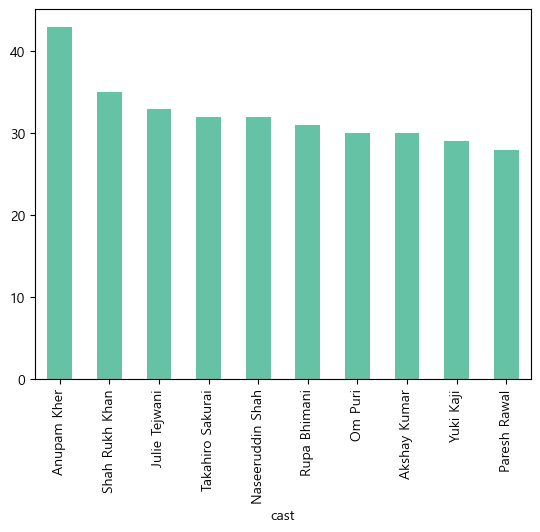

In [220]:
top_cast.plot(kind='bar')

In [ ]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

<Axes: xlabel='listed_in'>

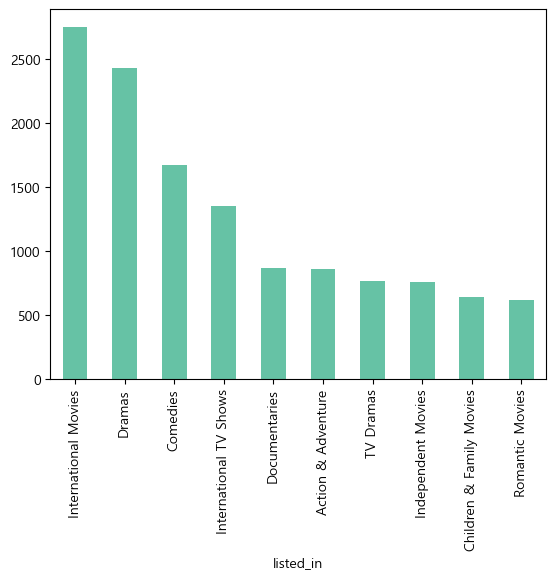

In [221]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

---

## PART 8. 데이터 시각화하기

> 숫자로 보는 것보다 **그래프로 보면** 패턴이 훨씬 잘 보입니다!  
> pandas `.plot()`, matplotlib.pyplot `plt`, seaborn `sns`

### 그래프 종류 선택 기준

| 그래프 | 언제 사용? |
|--------|----------|
| 막대 (bar/barh) | 항목 간 크기 비교 |
| 파이 (pie) | 전체 중 비율 |
| 선 (line) | 시간에 따른 변화 |
| 히스토그램 (hist) | 연속 숫자 분포 |
| 산점도 (scatter) | 두 변수 관계 |

#### pandas `.plot()` 으로 그래프 그리기

> Series/DataFrame 뒤에 `.plot(kind=종류)` 를 붙이면 바로 그래프가 됩니다.  
> `plt.title()`, `plt.xlabel()` 등으로 제목·레이블 등을 추가할 수 있습니다.

문제 1: 컨텐츠 타입 비율 - 파이 차트

<Axes: ylabel='count'>

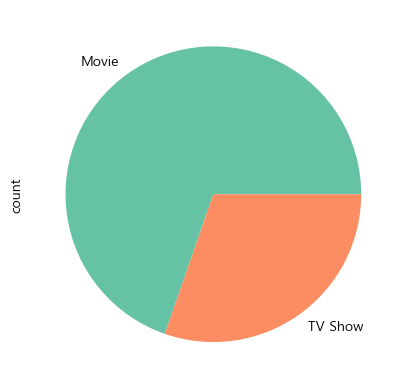

In [222]:
df['type'].value_counts().plot(kind='pie')

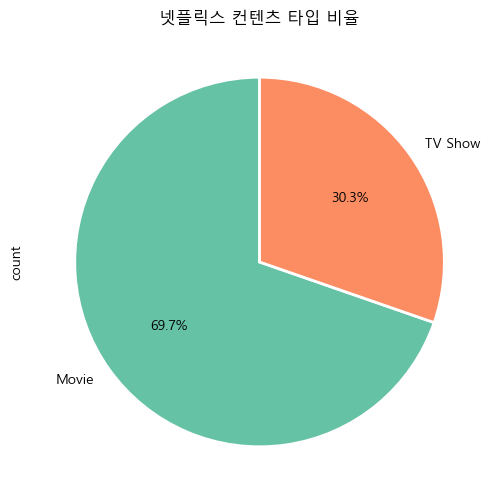

In [223]:
df['type'].value_counts().plot(kind='pie',
    figsize=(6, 6),
    autopct='%1.1f%%',      # 조각 안에 비율 표시
    startangle=90,          # 12시 방향에서 시작
     
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    title='넷플릭스 컨텐츠 타입 비율')

plt.show()

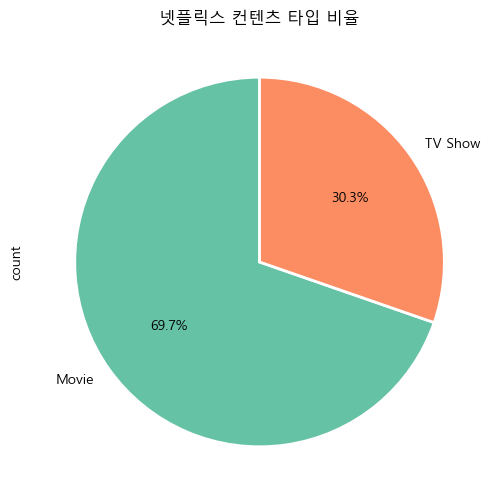

In [224]:
df['type'].value_counts().plot(kind='pie',
    figsize=(6, 6),
    autopct='%1.1f%%',      # 조각 안에 비율 표시
    startangle=90,          # 12시 방향에서 시작
     
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    title='넷플릭스 컨텐츠 타입 비율')

plt.show()

#### seaborn 으로 그래프 그리기

> `sns.함수명(data=DataFrame, x='컬럼', y='컬럼')` 형태로 사용합니다.  

문제 2: 시청 등급 분포 - seaborn countplot : 데이터를 받아 자동으로 개수를 세어서 막대로 표시

In [225]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='rating'>

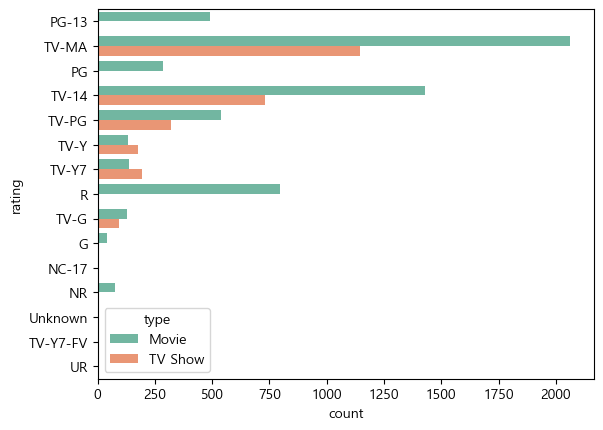

In [226]:
sns.countplot(data=df, y='rating', hue='type')

문제 3: 영화상영시간 분포- sns.histplot() :**연속적인 숫자** 데이터가 어떻게 분포하는지 확인

<Axes: ylabel='Frequency'>

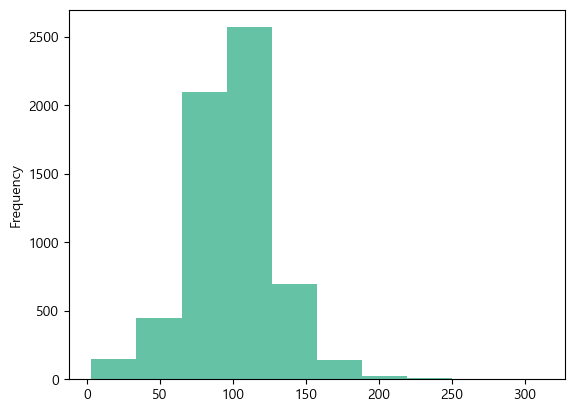

In [227]:
df_movie['duration'].plot(kind='hist')

<Axes: xlabel='duration', ylabel='Count'>

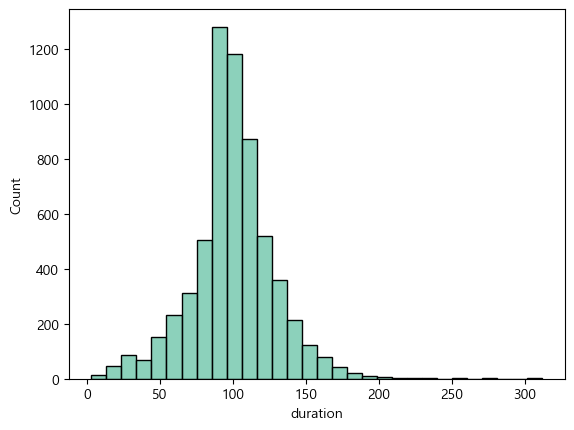

In [228]:
sns.histplot(data=df_movie, x='duration', bins=30)

문제 4: 컨텐츠 등록에 대한 요일 별 분포

In [229]:
df['weekday'] = df['date_added'].dt.day_name()

<Axes: xlabel='count', ylabel='weekday'>

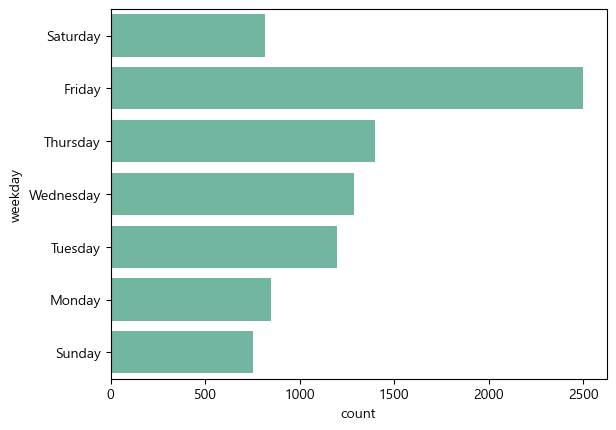

In [230]:
sns.countplot(data=df, y='weekday')

---

### 데이터 분석 기본 흐름

```
1. 라이브러리 불러오기  import 라이브러리이름 as 별명         

2. 불러오기    pd.read_csv()
      ↓
3. 탐색        head() / info() / describe()
      ↓
4. 정제        fillna() / dropna()
      ↓
5. 가공        to_datetime() / dt.year / dt.day_name()
               str.replace() / str.split().explode()
      ↓
6. 필터링      df[조건] / str.contains() / isin()
      ↓
7. 집계        value_counts() / groupby() / explode()
      ↓
8. 시각화      .plot() / sns.함수() / plt.함수()

```

---

### 문제 풀이 패턴 정리

```
[패턴 1] 기본 집계
  df['컬럼'].value_counts().head(n)

[패턴 2] 그룹핑
  df.groupby('그룹핑하는 기준 컬럼')['선택한 컬럼'].mean()
  
[패턴 3] 다중값 분리 집계 (배우, 장르)
  df['컬럼'].str.split(', ').explode().value_counts()

[패턴 4] 수치 추출 후 통계
  df['컬럼'].str.replace(' min','').astype(float).mean()

[패턴 5] 조건 필터링 후 집계
  df[조건]['컬럼'].value_counts()
```

`astype(float)` 대신 `astype(int)` 도 가능하지만, 변환 중 NaN이 있을 경우 `float` 이 더 안전합니다.

---
여러분 어떻게 공부하셨나요?     
어렵다는 생각보다는 우리가 데이터로 부터 이러한 것을 알아내고 있구나 하는 경험을 갖으면 됩니다     
그러한 경험이 여러분을 훌륭한 데이터 분석가의 길로 이끌게 됩니다    
공부하면서 느낀 **여러분의 이야기** 를 아래 셀에 피드백으로 반드시 적어주시기 바랍니다!!

In [ ]:
컬럼에서 문자열을 제거하고 astype(int)로 변환하여 수치 데이터로 만드는 과정이 제일 기억에 남았습니다.

In [ ]:
이 과정에서 데이터를 한 번 변환하면 타입이 바뀌기 때문에, 같은 코드를 중복 실행할 때 발생할 수 있는 오류를 경험하며 데이터 타입 관리의 중요성을 다시한번 느꼈습니다.